# Potentielles failles et améliorations des méthodes WRC et MCP

## Objectif du notebook

Ce notebook transforme le passage EBTA sur les failles potentielles du **White's Reality Check** (**WRC**) et de la **Monte Carlo Permutation Method** (**MCPM**) en intuition, simulation et code Python.

> **Idée centrale :** un test statistique ne doit pas seulement éviter les faux positifs. Il doit aussi conserver assez de **puissance statistique** pour ne pas rejeter une vraie règle gagnante par excès de prudence.

Nous allons construire une expérience simplifiée pour comprendre :

- pourquoi les règles très perdantes peuvent polluer la distribution du hasard ;
- comment cela peut augmenter le risque d'**Erreur de Type II** ;
- pourquoi une approche **stepwise**, inspirée de Romano-Wolf, peut rendre le test plus sensible ;
- comment relier cela à un workflow de **backtest** et de recherche de stratégies.

## 1. Le problème en une phrase

Dans un univers de minage, on teste souvent des centaines ou milliers de règles.

Le danger évident est l'**Erreur de Type I** :

> Croire qu'une stratégie possède un edge alors qu'elle n'a simplement eu que de la chance.

Le danger moins visible est l'**Erreur de Type II** :

> Rejeter une stratégie qui possède réellement un edge parce que le test est trop conservateur.

Le WRC et la MCPM corrigent le biais de data-mining, mais leur version initiale peut perdre de la **puissance statistique** lorsque l'univers testé contient beaucoup de règles très mauvaises.

## 2. Glossaire EBTA

| Terme | Définition simple | Application trading |
|---|---|---|
| **Hypothèse nulle** $H_0$ | Les règles n'ont aucun pouvoir prédictif réel | Les profits observés viennent du hasard |
| **p-value** | Probabilité d'obtenir une performance aussi extrême sous $H_0$ | Plus elle est faible, plus le résultat est suspect pour $H_0$ |
| **Erreur de Type I** | Faux positif | Trader une illusion statistique |
| **Erreur de Type II** | Faux négatif | Rejeter une règle réellement profitable |
| **Puissance statistique** | Capacité du test à détecter un vrai edge | Ne pas laisser une vraie pépite dans le sol |
| **WRC** | Test du meilleur candidat parmi plusieurs règles | Corrige la sélection du meilleur backtest |
| **MCPM** | Méthode par permutation Monte Carlo | Mélange signaux/rendements pour casser la prédictivité |
| **Romano-Wolf** | Procédure multiple par étapes | Améliore la puissance du test |

## 3. Intuition visuelle

Imaginons trois familles de règles :

1. des règles sans edge ;
2. une petite quantité de règles réellement gagnantes ;
3. beaucoup de règles très perdantes, parfois très volatiles.

Dans un test classique, on construit une distribution du **maximum de performance possible par hasard**.

Mais si l'univers contient des règles très mauvaises et très volatiles, leurs versions randomisées peuvent parfois créer des résultats extrêmes.

Résultat :

> La barre à franchir devient trop haute. Même une bonne règle peut sembler insuffisante.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def annualized_sharpe(returns, periods_per_year=252):
    """
    Calcule un Sharpe annualisé simple.

    Ce n'est pas une mesure parfaite, mais elle est pratique pour illustrer
    le mécanisme statistique du WRC/MCPM.
    """
    returns = np.asarray(returns)
    std = returns.std(ddof=1)
    if std == 0:
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / std

## 4. Création d'un univers de règles

Nous allons simuler un univers de règles de trading.

Chaque règle produit une série de rendements.

Dans cette expérience :

- la majorité des règles ont une espérance nulle ;
- certaines règles sont réellement gagnantes ;
- certaines règles sont fortement perdantes ;
- les règles perdantes peuvent avoir une variance élevée.

L'objectif est de voir comment ces règles perdantes peuvent perturber le test.

In [2]:
def simulate_rule_universe(
    n_obs=500,
    n_null=80,
    n_good=3,
    n_bad=80,
    good_mu=0.0007,
    bad_mu=-0.0012,
    null_mu=0.0,
    null_sigma=0.01,
    good_sigma=0.01,
    bad_sigma=0.025,
    seed=42
):
    """
    Simule un univers de règles.

    Chaque colonne représente une règle.
    Chaque ligne représente une observation temporelle.
    """
    rng = np.random.default_rng(seed)

    null_rules = rng.normal(null_mu, null_sigma, size=(n_obs, n_null))
    good_rules = rng.normal(good_mu, good_sigma, size=(n_obs, n_good))
    bad_rules = rng.normal(bad_mu, bad_sigma, size=(n_obs, n_bad))

    data = np.concatenate([null_rules, good_rules, bad_rules], axis=1)

    columns = (
        [f"null_{i+1}" for i in range(n_null)] +
        [f"good_{i+1}" for i in range(n_good)] +
        [f"bad_{i+1}" for i in range(n_bad)]
    )

    return pd.DataFrame(data, columns=columns)

rules = simulate_rule_universe()

observed_sharpes = rules.apply(annualized_sharpe)
observed_sharpes.sort_values(ascending=False).head(10)

null_38    2.070165
good_2     1.458320
null_72    1.442213
null_45    1.366435
null_34    1.274372
null_64    1.270414
good_3     1.141472
null_43    1.110019
null_11    0.969493
good_1     0.963080
dtype: float64

In [3]:
summary = pd.DataFrame({
    "rule": observed_sharpes.index,
    "sharpe": observed_sharpes.values,
    "family": [
        "good" if c.startswith("good") else "bad" if c.startswith("bad") else "null"
        for c in observed_sharpes.index
    ]
})

summary.groupby("family")["sharpe"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
family,,,,,,,,
bad,80.0,-0.900,0.658,-2.096,-1.262,-0.929,-0.449,0.804
good,3.0,1.188,0.251,0.963,1.052,1.141,1.300,1.458
null,80.0,0.071,0.753,-2.148,-0.365,0.111,0.630,2.070


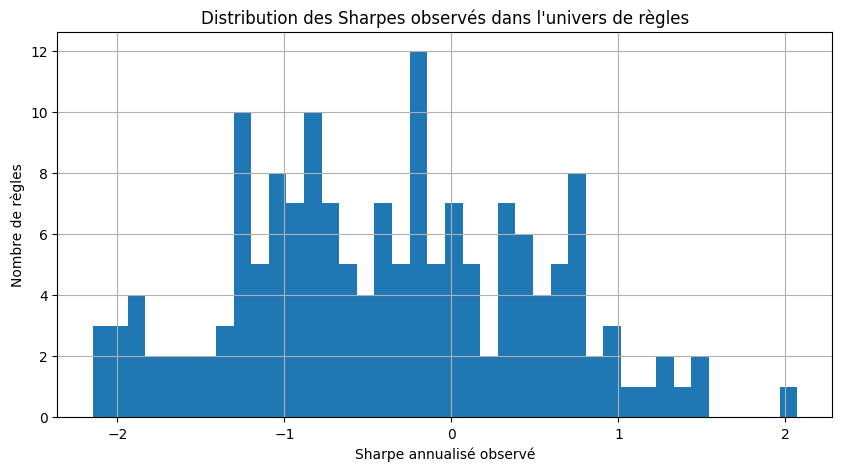

In [4]:
plt.figure(figsize=(10, 5))
summary["sharpe"].hist(bins=40)
plt.title("Distribution des Sharpes observés dans l'univers de règles")
plt.xlabel("Sharpe annualisé observé")
plt.ylabel("Nombre de règles")
plt.show()

## 5. WRC simplifié par bootstrap centré

Le WRC original est plus subtil que cette version pédagogique.

L'idée générale est :

1. on observe la meilleure performance parmi toutes les règles ;
2. on crée des mondes artificiels sous $H_0$ ;
3. dans chaque monde artificiel, on mesure le meilleur résultat obtenu par hasard ;
4. on compare la meilleure règle réelle à cette distribution du hasard.

La p-value approximative devient :

$$
p = \frac{1 + \#(\text{max hasard} \geq \text{meilleur observé})}{1 + B}
$$

où $B$ est le nombre de simulations bootstrap.

In [5]:
def simple_wrc_bootstrap_pvalue(rule_returns, n_boot=1000, seed=123):
    """
    Version pédagogique du WRC.

    Étapes :
    - on centre chaque règle pour représenter H0 ;
    - on bootstrap les lignes temporelles ;
    - on calcule le Sharpe de chaque règle bootstrapée ;
    - on garde le maximum de Sharpe obtenu dans chaque simulation.
    """
    rng = np.random.default_rng(seed)
    X = rule_returns.to_numpy()

    observed = np.array([annualized_sharpe(X[:, j]) for j in range(X.shape[1])])
    observed_best = np.nanmax(observed)

    X_centered = X - X.mean(axis=0, keepdims=True)
    n_obs, n_rules = X_centered.shape

    boot_max = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n_obs, size=n_obs)
        sample = X_centered[idx, :]
        sharpes = np.array([annualized_sharpe(sample[:, j]) for j in range(n_rules)])
        boot_max[b] = np.nanmax(sharpes)

    pvalue = (1 + np.sum(boot_max >= observed_best)) / (1 + n_boot)

    return {
        "observed_best": observed_best,
        "pvalue": pvalue,
        "boot_max": boot_max
    }

wrc_full = simple_wrc_bootstrap_pvalue(rules, n_boot=1000)

wrc_full["observed_best"], wrc_full["pvalue"]

(np.float64(2.0701654726529766), np.float64(0.26173826173826176))

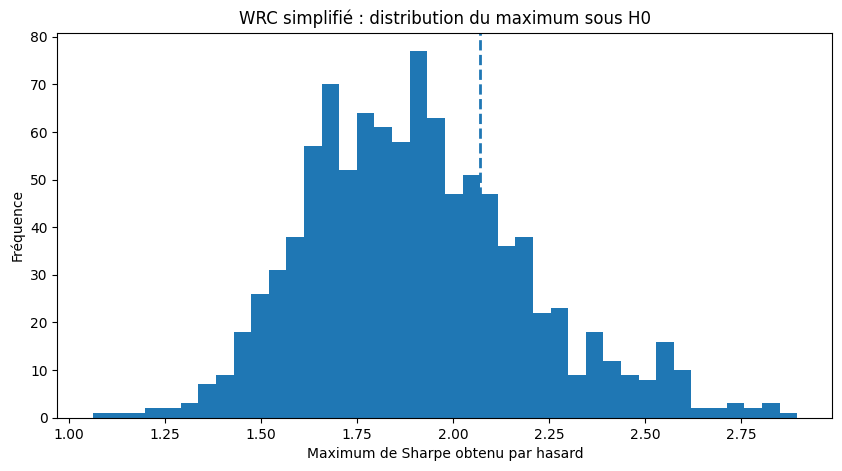

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(wrc_full["boot_max"], bins=40)
plt.axvline(wrc_full["observed_best"], linestyle="--", linewidth=2)
plt.title("WRC simplifié : distribution du maximum sous H0")
plt.xlabel("Maximum de Sharpe obtenu par hasard")
plt.ylabel("Fréquence")
plt.show()

## 6. Où apparaît la faille ?

Maintenant, comparons deux univers :

1. un univers complet avec règles nulles, gagnantes et très perdantes ;
2. un univers nettoyé où l'on retire les règles fortement négatives.

Dans l'esprit de la critique de Hansen, les règles très mauvaises peuvent réduire la puissance du test parce qu'elles élargissent ou perturbent la distribution du hasard.

L'effet exact dépend de la structure des rendements, de la variance, du nombre de règles et de la méthode de randomisation.

In [7]:
rules_without_bad = rules[[c for c in rules.columns if not c.startswith("bad")]]

wrc_without_bad = simple_wrc_bootstrap_pvalue(rules_without_bad, n_boot=1000, seed=123)

comparison = pd.DataFrame({
    "univers": ["Complet : null + good + bad", "Nettoyé : null + good"],
    "nb_regles": [rules.shape[1], rules_without_bad.shape[1]],
    "meilleur_sharpe_observe": [wrc_full["observed_best"], wrc_without_bad["observed_best"]],
    "p_value_wrc_simplifiee": [wrc_full["pvalue"], wrc_without_bad["pvalue"]],
    "seuil_95pct_hasard": [
        np.quantile(wrc_full["boot_max"], 0.95),
        np.quantile(wrc_without_bad["boot_max"], 0.95)
    ]
})

comparison.round(4)

,univers,nb_regles,meilleur_sharpe_observe,p_value_wrc_simplifiee,seuil_95pct_hasard
0,Complet : null + good + bad,163,2.0702,0.2617,2.4659
1,Nettoyé : null + good,83,2.0702,0.1449,2.2878


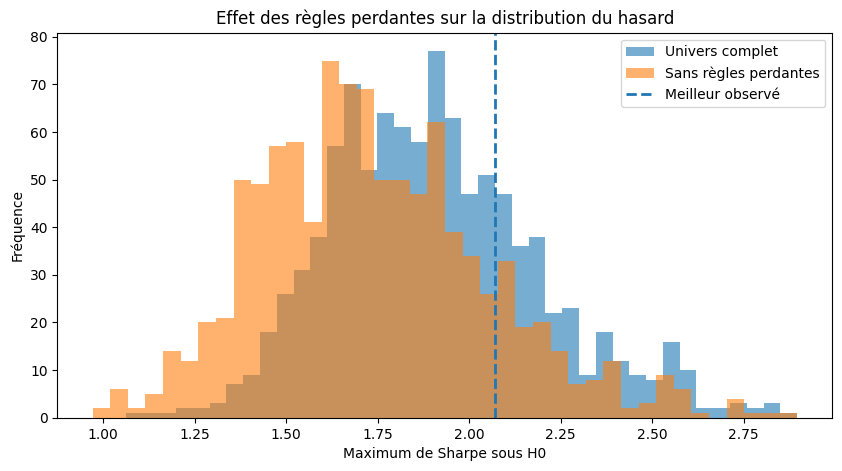

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(wrc_full["boot_max"], bins=40, alpha=0.6, label="Univers complet")
plt.hist(wrc_without_bad["boot_max"], bins=40, alpha=0.6, label="Sans règles perdantes")
plt.axvline(wrc_full["observed_best"], linestyle="--", linewidth=2, label="Meilleur observé")
plt.title("Effet des règles perdantes sur la distribution du hasard")
plt.xlabel("Maximum de Sharpe sous H0")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 7. Version stepwise inspirée Romano-Wolf

Une procédure **stepwise** ne traite pas l'univers comme un bloc figé.

Elle procède par étapes :

1. calculer les statistiques observées ;
2. identifier les règles trop faibles ou non pertinentes ;
3. recalculer la distribution multiple sur l'ensemble restant ;
4. ajuster les décisions de rejet en tenant compte des tests multiples.

Le vrai algorithme Romano-Wolf est plus rigoureux que la version ci-dessous.

Ici, nous construisons une approximation pédagogique :

- on retire les règles dont la performance observée est négative ;
- on refait le WRC simplifié sur les survivantes ;
- on compare le seuil obtenu.

> **But pédagogique :** comprendre pourquoi retirer les règles qui polluent le test peut augmenter la puissance.

In [9]:
def pedagogical_stepwise_filter(rule_returns, min_observed_sharpe=0.0):
    """
    Filtre pédagogique inspiré d'une logique stepwise.

    Attention :
    ceci n'est PAS une implémentation académique complète de Romano-Wolf.

    On garde seulement les règles dont le Sharpe observé dépasse un seuil.
    """
    sharpes = rule_returns.apply(annualized_sharpe)
    kept_cols = sharpes[sharpes >= min_observed_sharpe].index.tolist()
    return rule_returns[kept_cols], sharpes

stepwise_rules, all_sharpes = pedagogical_stepwise_filter(rules, min_observed_sharpe=0.0)

wrc_stepwise = simple_wrc_bootstrap_pvalue(stepwise_rules, n_boot=1000, seed=123)

stepwise_comparison = pd.DataFrame({
    "methode": ["WRC simplifié complet", "WRC filtrage stepwise pédagogique"],
    "nb_regles": [rules.shape[1], stepwise_rules.shape[1]],
    "meilleur_sharpe_observe": [wrc_full["observed_best"], wrc_stepwise["observed_best"]],
    "p_value": [wrc_full["pvalue"], wrc_stepwise["pvalue"]],
    "seuil_95pct_hasard": [
        np.quantile(wrc_full["boot_max"], 0.95),
        np.quantile(wrc_stepwise["boot_max"], 0.95)
    ]
})

stepwise_comparison.round(4)

,methode,nb_regles,meilleur_sharpe_observe,p_value,seuil_95pct_hasard
0,WRC simplifié complet,163,2.0702,0.2617,2.4659
1,WRC filtrage stepwise pédagogique,53,2.0702,0.0949,2.2075


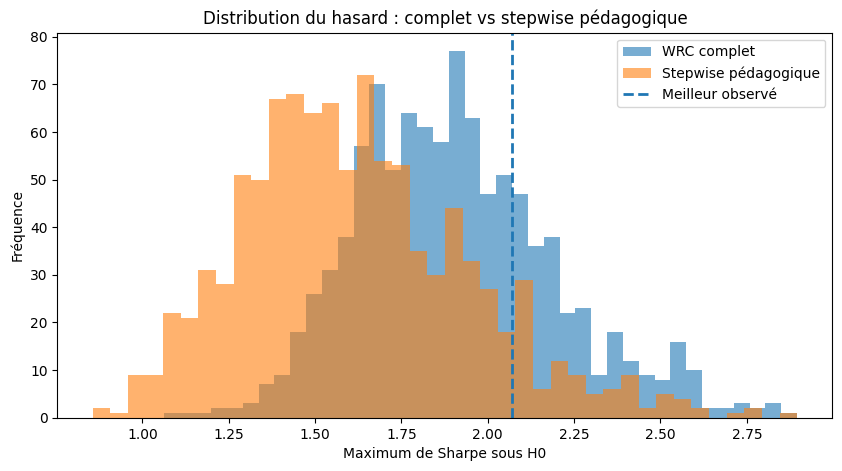

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(wrc_full["boot_max"], bins=40, alpha=0.6, label="WRC complet")
plt.hist(wrc_stepwise["boot_max"], bins=40, alpha=0.6, label="Stepwise pédagogique")
plt.axvline(wrc_full["observed_best"], linestyle="--", linewidth=2, label="Meilleur observé")
plt.title("Distribution du hasard : complet vs stepwise pédagogique")
plt.xlabel("Maximum de Sharpe sous H0")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 8. MCPM simplifiée : permutation signaux/rendements

La MCPM détruit le lien entre le signal et le rendement en réappariant aléatoirement les observations.

Dans une version trading :

- les rendements de marché sont conservés ;
- les signaux sont mélangés ou réassignés ;
- la structure réelle du marché reste présente ;
- mais le pouvoir prédictif du signal est cassé.

Ici, nous simulons des signaux $+1/-1$ et un rendement de marché commun.

In [11]:
def simulate_signal_universe(
    n_obs=500,
    n_null=80,
    n_good=3,
    n_bad=80,
    seed=7
):
    """
    Simule des règles sous forme de signaux +1/-1 appliqués à un rendement marché.
    """
    rng = np.random.default_rng(seed)

    market_returns = rng.normal(0, 0.01, size=n_obs)
    future_direction = np.sign(market_returns)
    future_direction[future_direction == 0] = 1

    signals = []
    names = []

    for i in range(n_null):
        signals.append(rng.choice([-1, 1], size=n_obs))
        names.append(f"null_{i+1}")

    for i in range(n_good):
        noise = rng.choice([-1, 1], size=n_obs, p=[0.25, 0.75])
        signals.append(future_direction * noise)
        names.append(f"good_{i+1}")

    for i in range(n_bad):
        noise = rng.choice([-1, 1], size=n_obs, p=[0.25, 0.75])
        signals.append(-future_direction * noise)
        names.append(f"bad_{i+1}")

    signals = pd.DataFrame(np.array(signals).T, columns=names)
    strategy_returns = signals.mul(market_returns, axis=0)

    return market_returns, signals, strategy_returns

market_returns, signals, strategy_returns = simulate_signal_universe()

mcpm_sharpes = strategy_returns.apply(annualized_sharpe)
mcpm_sharpes.sort_values(ascending=False).head(10)

good_3     7.321682
good_2     6.965772
good_1     6.289381
null_33    1.800322
null_70    1.610896
null_27    1.515563
null_6     1.062641
null_45    0.978488
null_4     0.927852
null_80    0.910218
dtype: float64

In [12]:
def simple_mcpm_pvalue(signals, market_returns, n_perm=1000, seed=999):
    """
    Version pédagogique de la MCPM.

    On permute les rendements de marché, puis on recalcule les performances
    des règles sur ces rendements mélangés.
    """
    rng = np.random.default_rng(seed)

    S = signals.to_numpy()
    r = np.asarray(market_returns)

    observed_returns = S * r.reshape(-1, 1)
    observed_sharpes = np.array([annualized_sharpe(observed_returns[:, j]) for j in range(S.shape[1])])
    observed_best = np.nanmax(observed_sharpes)

    perm_max = np.empty(n_perm)

    for b in range(n_perm):
        perm_r = rng.permutation(r)
        perm_returns = S * perm_r.reshape(-1, 1)
        sharpes = np.array([annualized_sharpe(perm_returns[:, j]) for j in range(S.shape[1])])
        perm_max[b] = np.nanmax(sharpes)

    pvalue = (1 + np.sum(perm_max >= observed_best)) / (1 + n_perm)

    return {
        "observed_best": observed_best,
        "pvalue": pvalue,
        "perm_max": perm_max
    }

mcpm_full = simple_mcpm_pvalue(signals, market_returns, n_perm=1000)
mcpm_full["observed_best"], mcpm_full["pvalue"]

(np.float64(7.321682187376301), np.float64(0.000999000999000999))

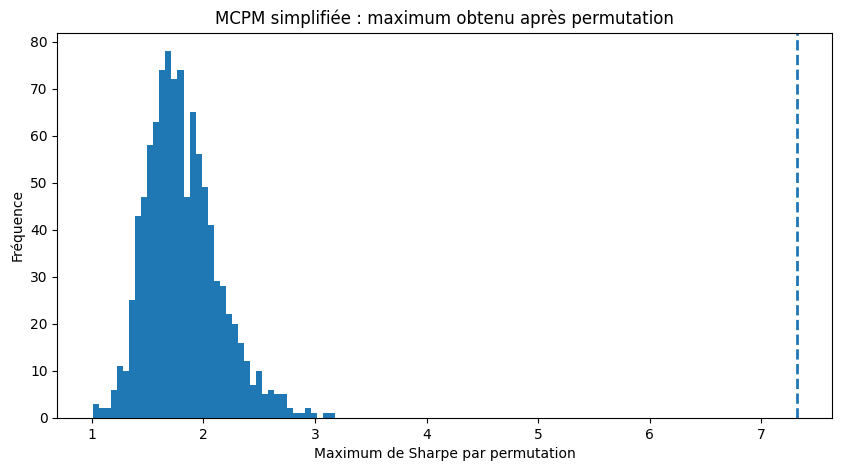

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(mcpm_full["perm_max"], bins=40)
plt.axvline(mcpm_full["observed_best"], linestyle="--", linewidth=2)
plt.title("MCPM simplifiée : maximum obtenu après permutation")
plt.xlabel("Maximum de Sharpe par permutation")
plt.ylabel("Fréquence")
plt.show()

## 9. Limites et erreurs fréquentes

### Limites

- **Implémentation incomplète ici :** le notebook donne une simulation pédagogique, pas un package académique complet.
- **Hypothèses simplifiées :** les rendements simulés sont plus propres que des rendements réels.
- **Corrélation entre règles :** dans la vraie vie, les règles sont souvent fortement corrélées.
- **Dépendance temporelle :** un vrai marché contient autocorrélation, volatilité en régime, gaps et coûts d'exécution.
- **Coûts de transaction absents :** commissions, spread, slippage et market impact peuvent détruire un edge.
- **Romano-Wolf réel :** la vraie méthode demande une procédure de tests multiples plus précise qu'un simple filtrage des règles négatives.

### Erreurs fréquentes

| Erreur | Pourquoi c'est dangereux |
|---|---|
| Confondre **puissance du test** et **edge de la règle** | Un bon test peut détecter un edge, mais ne le crée pas |
| Penser que plus sévère = toujours meilleur | Trop de sévérité augmente l'Erreur de Type II |
| Tester des milliers de variantes sans correction | Cela gonfle massivement le biais de data-mining |
| Mélanger règles normales et inverses sans réfléchir | Les inverses très mauvais peuvent polluer l'univers |
| Regarder seulement la meilleure equity curve | C'est précisément le piège que WRC/MCPM cherchent à corriger |

## 10. Checklist EBTA pour un vrai pipeline quant

Avant de valider une règle issue d'un backtest intensif, vérifier :

- **Univers testé documenté :** toutes les variantes doivent être listées.
- **Nombre réel de règles :** ne pas cacher les essais ratés.
- **Correction multiple :** WRC, MCPM, Romano-Wolf ou équivalent.
- **Puissance statistique :** ne pas seulement regarder l'Erreur de Type I.
- **Règles inverses séparées :** analyser si elles polluent la distribution.
- **Coûts inclus :** spread, slippage, commissions.
- **Robustesse temporelle :** walk-forward, sous-périodes, régimes de volatilité.
- **Intervalles de confiance joints :** préférables aux intervalles isolés.

## 11. Eurêka final

> **Le WRC et la MCPM ne sont pas seulement des freins contre l'illusion statistique. Ce sont des instruments de détection. Mais un instrument trop conservateur peut devenir aveugle au vrai signal.**

L'amélioration Romano-Wolf rappelle une leçon essentielle :

> **Un bon test ne doit pas seulement protéger contre les faux edges. Il doit aussi préserver la capacité à reconnaître un edge réel.**

Pour ton approche EBTA, cela signifie :

- ne pas valider une stratégie parce qu'elle a la meilleure courbe ;
- ne pas la rejeter trop vite parce qu'un test mal calibré est trop sévère ;
- construire un protocole où la **rigueur** et la **puissance** avancent ensemble.

## 12. Mini-exercice

Modifie les paramètres suivants dans les fonctions de simulation :

- `n_good`
- `n_bad`
- `good_mu`
- `bad_sigma`
- `n_obs`

Observe ensuite :

1. la p-value du WRC simplifié ;
2. la p-value après filtrage stepwise pédagogique ;
3. le seuil à 95\% de la distribution du hasard ;
4. la capacité du test à détecter les règles gagnantes.

Question clé :

> À partir de quel moment l'univers de recherche devient-il tellement pollué que le test classique perd sa capacité à détecter le signal ?

## Annexe — Texte source fourni

# POTENTIELLES FAILLES ET AMÉLIORATIONS DES MÉTHODES WRC ET MCP

## Référence
*   **Titre :** Potential Flaws in Initial WRC and MCP Methods & Recent Enhancement to WRC and MCP
*   **Chapitre :** Chapitre 6 : Data-Mining Bias
*   **Pages :** 329 – 330
*   **Thème principal :** L'amélioration de la puissance statistique des tests de significativité pour le minage de données.

## Idées clés
1.  **La puissance statistique** — Elle définit la capacité d'un test à rejeter l'hypothèse nulle ($H_0$) lorsqu'elle est réellement fausse (c'est-à-dire sa capacité à détecter un "edge" réel). (Page 329)
2.  **L'influence des règles perdantes** — La présence de règles affichant des rendements inférieurs au benchmark (règles négatives) réduit la puissance des tests WRC et MCP originaux. (Page 329)
3.  **Erreur de Type II** — C'est le risque de rejeter une règle qui possède un pouvoir prédictif réel parce que le test est trop conservateur ou "sévère". (Page 329)
4.  **L'amélioration Romano-Wolf** — Une modification statistique qui augmente la puissance du WRC et de la MCPM, réduisant ainsi la probabilité de l'erreur de Type II. (Page 330)

## Citation directe
> “Romano and Wolf recommends a modification that enhances the power of WRC and that also appears to enhance the power of MCP. Thus the Romano and Wolf enhancement reduces the probability of a Type-II error.” (Page 330)

## Vision macro
L'enjeu ici est l'équilibre entre **prudence** et **efficacité**.

## Vision micro
Le mécanisme technique de cette faille et de sa solution repose sur la structure de l'univers de minage.

## Limites et erreurs fréquentes
### Limites
* **Disponibilité commerciale :** au moment de la publication, Aronson note qu'aucune version commerciale de WRC ne possédait encore cette amélioration.
* **Complexité mathématique :** la mise en œuvre de Romano-Wolf est plus complexe qu'un bootstrap simple.

### Erreurs fréquentes
* **Confondre puissance et pouvoir prédictif**
* **Ignorer l'erreur de Type II**

## À retenir absolument
* L'amélioration Romano-Wolf améliore la puissance statistique.
* Elle réduit le risque de rejeter par erreur une bonne stratégie.